# Tutorial showing how to runa WFI simulation *without* any sources and a simplified model of the background. 

Then goes on to extract spectra.

Work in progress - builds on tutorial-wfi-field-with-backgrounds

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import tempfile
from funcs import run_comm,showximage
import matplotlib.pyplot as plt
from astropy.io import fits

from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)


### Setup to run the SIXTE simulation

Note this assumes you have setup the "SIXTE" and "SIMPUT" environment variables correctly for these software to work

In [4]:
tmpDir = tempfile.mkdtemp()
os.environ["PFILES"] = tmpDir + ":" + os.environ["PFILES"]
os.environ["HEADASNOQUERY"] = ""
os.environ["HEADASPROMPT"] = "/dev/null/"
SIXTE = os.environ["SIXTE"]
SIMPUT = os.environ["SIMPUT"]
xmldir = f"{SIXTE}/share/sixte/instruments/athena-wfi/wfi_w_filter" # N.B. default recommendation from WFI team is now to assume *with* the filter.
bkgfile= f"{SIXTE}/share/sixte/foreground_release/combined_linescan_foreground_qe_w_filter_cluster_removed.fits" 
# N.B. w/ filter. "cluster removed" indicates a birght cluster in the inputs used to generate the stray estimate is removed. 
# The straylight is technically for a line scan observation but as events re recorded in detector co-ordinates it provides a reasonable average for a single (dithered) pointing as simulated here.

prefix='wfibkgsim/' # prefix for output simulation files (/ stores to a directory)
os.makedirs(prefix, exist_ok=True)

xml=f'{xmldir}/ld_wfi_ff_all_chips.xml'

exptime=500 # in ks

### Creating a SIMPUT file to capture the soft Galactic foreground *and* any unresolved AGN

We adopt the model described here: https://www.mpe.mpg.de/ATHENA-WFI/public/resources/background/WFI-MPE-ANA-10-013_i9.6_Preparation_of_Background_Files.pdf

Simulate for a 50x50 arcmin region centred on RA=0.0, Dec=0.0

srcFLux is the total 0.1-15 keV flux in this region (as the model is defined per sq arcmin need to multiply the flux in xspec x 50 x 50)

In [8]:
comm = f'{SIXTE}/bin/simputfile Simput=focussed_backgrounds.simput Src_ID=1 Src_Name=focussedbkg ' \
        'RA=0.0 Dec=0.0 XSPECFILE=focussed_backgrounds.xcm ' \
        'Emin=0.1 Emax=15 Nbins=5000 logEgrid=yes ' \
        'srcFlux=2.110725e-11 ' \
        'clobber=yes ' \
        'ImageFile=50x50arcmin_flat_img.fits '
run_comm(comm)




/Users/ja457/software/sixte/bin/simputfile Simput=focussed_backgrounds.simput Src_ID=1 Src_Name=focussedbkg RA=0.0 Dec=0.0 XSPECFILE=focussed_backgrounds.xcm Emin=0.1 Emax=15 Nbins=5000 logEgrid=yes srcFlux=2.110725e-11 clobber=yes ImageFile=50x50arcmin_flat_img.fits 
finished successfully!


		XSPEC version: 12.15.1
	Build Date/Time: Thu Jul  9 20:56:13 2026


!XSPEC12>statistic chi
Default fit statistic is set to: Chi-Squared
   This will apply to all current and newly loaded spectra.

!XSPEC12>method leven 10 0.01

!XSPEC12>abund angr
 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)

!XSPEC12>xsect bcmc
 Cross Section Table set to bcmc:  Balucinska-Church and McCammon, 1998

!XSPEC12>cosmo 70 0 0.73

!XSPEC12>xset delta 0.01
Parameter delta values for fits will now be 0.01 * parValue

!XSPEC12>systematic 0

 The default systematic error for models is set to 0


!XSPEC12>model  apec + phabs*(apec+bknpower)  ;            0.0

### generate attitude for lissajous dither

In [9]:
comm='attgen_dither '\
     f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
     'Amplitude=0.035 '\
     'SrcRA=0.0 '\
     'SrcDec=0.0 '\
     f'Exposure={exptime*1000:.0f} '\
     'clobber=yes'
run_comm(comm)


attgen_dither Attitude=attitude_lissajous_500ks.fits Amplitude=0.035 SrcRA=0.0 SrcDec=0.0 Exposure=500000 clobber=yes


## Now run sixtesim
This shoudl be quicker than generating a simulation with actual sources!

In [10]:
comm= f'{SIXTE}/bin/sixtesim '\
      f'XMLFile={xml} '\
      f'RA=0.0 Dec=0.0 '\
      f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
      f'Prefix={prefix} '\
      f'Simput=focussed_backgrounds.simput '\
      f'EvtFile=evt.fits '\
      f'Exposure={exptime*1000} clobber=yes chatter=1 '\
      f'BkgEventFile={bkgfile}'
run_comm(comm)


/Users/ja457/software/sixte/bin/sixtesim XMLFile=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter/ld_wfi_ff_all_chips.xml RA=0.0 Dec=0.0 Attitude=attitude_lissajous_500ks.fits Prefix=wfibkgsim/ Simput=focussed_backgrounds.simput EvtFile=evt.fits Exposure=500000 clobber=yes chatter=1 BkgEventFile=/Users/ja457/software/sixte/share/sixte/foreground_release/combined_linescan_foreground_qe_w_filter_cluster_removed.fits
Seed = 2545582879

*** Warning in convSimputMIdpSpecWithARF: the spectrum 'focussed_backgrounds.simput[SPECTRUM,1]' does not cover the full energy range of the ARF! ***


### Merge chips files with ftmerge

In [25]:
comm= f'ftmerge '\
      f'{prefix}/chip0_evt.fits,{prefix}/chip1_evt.fits,{prefix}/chip2_evt.fits,{prefix}/chip3_evt.fits '\
      f'{prefix}/combined_evt.fits clobber=yes'
run_comm(comm)


ftmerge wfibkgsim//chip0_evt.fits,wfibkgsim//chip1_evt.fits,wfibkgsim//chip2_evt.fits,wfibkgsim//chip3_evt.fits wfibkgsim//combined_evt.fits clobber=yes


### Make an image of all events

In [27]:
comm= f'{SIXTE}/bin/imgev '\
      f'EvtFile={prefix}/combined_evt.fits  '\
      f'Image={prefix}/full_img.fits  '\
      f'CoordinateSystem=0 Projection=TAN '\
      f'NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg '\
      f'CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 '\
      f'CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true '\
      f'clobber=yes'
run_comm(comm)




/Users/ja457/software/sixte/bin/imgev EvtFile=wfibkgsim//combined_evt.fits  Image=wfibkgsim//full_img.fits  CoordinateSystem=0 Projection=TAN NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true clobber=yes
initialize ...
open event file 'wfibkgsim//combined_evt.fits' ...
finished successfully!



(<Figure size 1400x800 with 2 Axes>, <WCSAxes: >)

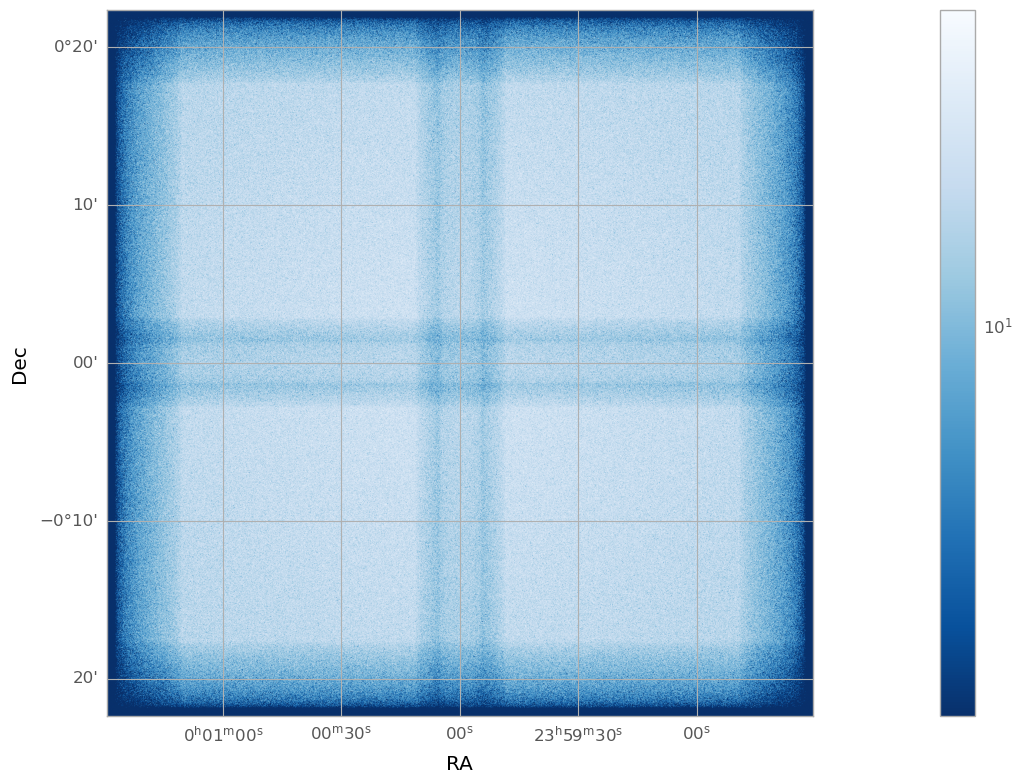

In [28]:
showximage(prefix+'full_img.fits')

##  Add RA and Dec to the events file

In [29]:
comm= f'{SIXTE}/bin/radec2xy '\
      f'EvtFile={prefix}/combined_evt.fits  '\
      f'projection=TAN '\
      f'RefRA=0.0 RefDec=0.0'
run_comm(comm)



/Users/ja457/software/sixte/bin/radec2xy EvtFile=wfibkgsim//combined_evt.fits  projection=TAN RefRA=0.0 RefDec=0.0
initialization ...
open event file 'wfibkgsim//combined_evt.fits' ...
add XY coordinates to event file ...
 ... adding X, Y coordinates successful!
cleaning up ...
finished successfully!



## Now let's extract spectra to caputre the background at different off-axis angles

In [53]:
combined_file = f'{prefix}/combined_evt.fits'
for extrad in [9.0,45.0,90.0]: # in arcsec
    for oaa in [0,2,4,8,12,16,20]:
        ra_src = oaa/60*np.cos((oaa/60)*np.pi/180)
        dec_src = oaa/60
        with open(f'{prefix}/extreg.reg', 'w', encoding='utf-8') as file:
            file.write(f'fk5;circle({ra_src},{dec_src},{extrad}\")')
        spec_file = f'{prefix}/spec_{oaa:.0f}arcmin_offaxis_{extrad}arcsec_extrad.pha'
        comm = (f"makespec EvtFile={combined_file} Spectrum={spec_file} clobber=yes RSPPath={xmldir} regfile={prefix}/extreg.reg")
        run_comm(comm, f'Generating spectrum for {oaa} arcmin off-axis')
        # generate correct ARF
        arfname=f"spec_{oaa:.0f}arcmin_offaxis_{extrad}arcsec_extrad.arf"
        comm = (f"sixte_arfgen ARFCorr={prefix}/{arfname} XMLFile={xml} RA=0.0 Dec=0.0 SourceRA={ra_src} SourceDec={dec_src} "\
                f"RefRA=0.0 RefDec=0.0 regfile={prefix}/extreg.reg "\
                f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
                f'TSTART=0 Exposure={exptime*1000:.0f} clobber=yes')
        run_comm(comm, f'Generating arf for {oaa} arcmin off-axis, {extrad}arcsec extraction region')
        # update rmf and arf in spec file
        f = fits.open(spec_file,'update')
        rmf = f[1].header['RESPFILE']
        rmfshort=os.path.basename(rmf)
        run_comm(f'cp -f {rmf} {prefix}/{rmfshort}')
        f[1].header['RESPFILE']=rmfshort
        f[1].header['ANCRFILE']=arfname
        f.close()

Generating spectrum for 0 arcmin off-axis
makespec EvtFile=wfibkgsim//combined_evt.fits Spectrum=wfibkgsim//spec_0arcmin_offaxis_9.0arcsec_extrad.pha clobber=yes RSPPath=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter regfile=wfibkgsim//extreg.reg
SIXTE version 3.4.0
***SPII_read_key: Cannot find DETNAM keyword - setting it to UNKNOWN
***SPII_read_key: Cannot find EFFAREA keyword - setting it to 1.000000
***SPII_read_key: Cannot find DETNAM keyword - setting it to UNKNOWN
***SPII_read_key: Cannot find EFFAREA keyword - setting it to 1.000000
Seed = 3863553078
calculate spectrum ...
store spectrum ...
Generating arf for 0 arcmin off-axis
sixte_arfgen ARFCorr=wfibkgsim//spec_0arcmin_offaxis_9.0arcsec_extrad.arf XMLFile=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter/ld_wfi_ff_all_chips.xml RA=0.0 Dec=0.0 SourceRA=0.0 SourceDec=0.0 RefRA=0.0 RefDec=0.0 regfile=wfibkgsim//extreg.reg Attitude=attitude_lissajous_500ks.fits TSTART=0 Expo